In [ ]:
#!pip install -U transformers
!pip install -U accelerate
#!pip install -U datsets # to install the huggingface dataset
!pip install -U bertviz
!pip install -U umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.4 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade --pre datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 28.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.


DATA ANALYSIS

In [ ]:
import pandas as pd

In [ ]:
test_df = pd.read_csv('/content/test.txt')
train_df = pd.read_csv('/content/train.txt',sep=",")
val_df = pd.read_csv('/content/val.txt')

In [ ]:
train_df.head()

,i didnt feel humiliated;sadness
0,i can go from feeling so hopeless to so damned...
1,im grabbing a minute to post i feel greedy wro...
2,i am ever feeling nostalgic about the fireplac...
3,i am feeling grouchy;anger
4,ive been feeling a little burdened lately wasn...


In [ ]:
# split emotion into a separate column::
train_df[['text', 'label']] = train_df.iloc[:,0].str.split(';', expand=True)

In [ ]:
train_df.head()

,i didnt feel humiliated;sadness,text,label
0,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,sadness
1,im grabbing a minute to post i feel greedy wro...,im grabbing a minute to post i feel greedy wrong,anger
2,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,love
3,i am feeling grouchy;anger,i am feeling grouchy,anger
4,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...,sadness


In [ ]:
# mapping numerical classes
label_to_id = {
    "sadness": 0,
    "joy": 1,
    "love": 2,
    "anger": 3,
    "fear": 4

}


In [ ]:
train_df['classes'] = train_df['label'].map(label_to_id)


In [ ]:
train_df.head()

,i didnt feel humiliated;sadness,text,label,classes
0,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,sadness,0.0
1,im grabbing a minute to post i feel greedy wro...,im grabbing a minute to post i feel greedy wrong,anger,3.0
2,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,love,2.0
3,i am feeling grouchy;anger,i am feeling grouchy,anger,3.0
4,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...,sadness,0.0


In [ ]:
test_df.head()

,im feeling rather rotten so im not very ambitious right now;sadness
0,im updating my blog because i feel shitty;sadness
1,i never make her separate from me because i do...
2,i left with my bouquet of red and yellow tulip...
3,i was feeling a little vain when i did this on...
4,i cant walk into a shop anywhere where i do no...


In [ ]:
train_df = train_df.drop(train_df.columns[0], axis=1)

In [ ]:
train_df.head()

,text,label,classes
0,i can go from feeling so hopeless to so damned...,sadness,0.0
1,im grabbing a minute to post i feel greedy wrong,anger,3.0
2,i am ever feeling nostalgic about the fireplac...,love,2.0
3,i am feeling grouchy,anger,3.0
4,ive been feeling a little burdened lately wasn...,sadness,0.0


In [ ]:
# drop surprise in the train dataset:
indexes_to_drop = []
for i in range(len(train_df)):
    if train_df.loc[i, "label"] == "surprise":
        indexes_to_drop.append(i)
train_df = train_df.drop(indexes_to_drop)

In [ ]:
print((train_df["label"] == "surprise").sum())

0


In [ ]:
# do the same for the test and validation dataset
test_df[['text', 'label']] = test_df.iloc[:,0].str.split(';', expand=True)
test_df = test_df.drop(test_df.columns[0], axis=1)

In [ ]:
val_df[['text', 'label']] = val_df.iloc[:,0].str.split(';', expand=True)
val_df = val_df.drop(val_df.columns[0], axis=1)

In [ ]:
test_df.head()

,text,label
0,im updating my blog because i feel shitty,sadness
1,i never make her separate from me because i do...,sadness
2,i left with my bouquet of red and yellow tulip...,joy
3,i was feeling a little vain when i did this one,sadness
4,i cant walk into a shop anywhere where i do no...,fear


In [ ]:
# drop surprise in the test dataset:
test_indexes_to_drop = []
for i in range(len(test_df)):
  if test_df.loc[i,"label"] =="surprise":
    test_indexes_to_drop.append(i)

test_df = test_df.drop(test_indexes_to_drop)

In [ ]:
print((test_df["label"] == "surprise").sum())

0


In [ ]:
val_df.head()

,text,label
0,i feel like i am still looking at a blank canv...,sadness
1,i feel like a faithful servant,love
2,i am just feeling cranky and blue,anger
3,i can have for a treat or if i am feeling festive,joy
4,i start to feel more appreciative of what god ...,joy


In [ ]:
# drop surprise in the val dataset:
val_indexes_to_drop = []
for i in range(len(val_df)):
  if val_df.loc[i,"label"] =="surprise":
    val_indexes_to_drop.append(i)

val_df = val_df.drop(val_indexes_to_drop)

In [ ]:
print((val_df["label"] == "surprise").sum())

0


In [ ]:
test_df['classes'] = test_df['label'].map(label_to_id)
val_df['classes'] = val_df['label'].map(label_to_id)

In [ ]:
test_df.head()

,text,label,classes
0,im updating my blog because i feel shitty,sadness,0
1,i never make her separate from me because i do...,sadness,0
2,i left with my bouquet of red and yellow tulip...,joy,1
3,i was feeling a little vain when i did this one,sadness,0
4,i cant walk into a shop anywhere where i do no...,fear,4


In [ ]:
val_df.head()

,text,label,classes
0,i feel like i am still looking at a blank canv...,sadness,0
1,i feel like a faithful servant,love,2
2,i am just feeling cranky and blue,anger,3
3,i can have for a treat or if i am feeling festive,joy,1
4,i start to feel more appreciative of what god ...,joy,1


DATA ANALYSIS ON THE TRAINING DATASET

In [ ]:
# check which emotions are present and the number of each in the dataset
train_df['label'].value_counts()

,count
label,
joy,5362
sadness,4665
anger,2159
fear,1937
love,1304


In [ ]:
train_df['label'].value_counts(normalize=True)

,proportion
label,
joy,0.347572
sadness,0.302392
anger,0.139949
fear,0.125559
love,0.084527


In [ ]:
!pip install wordcloud
import matplotlib.pyplot as plt

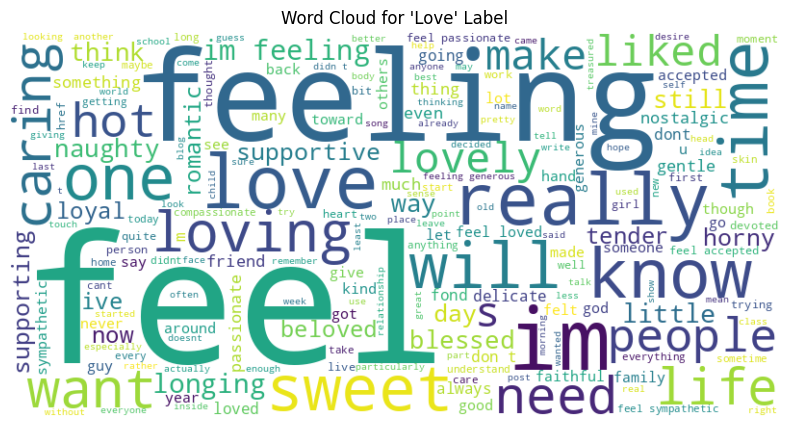

In [ ]:
# check common words for text labelled for each emotion
from wordcloud import WordCloud
#love
love_texts = train_df[train_df["label"] == "love"]["text"]
love_text = " ".join(love_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(love_text)



plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for 'Love' Label")
plt.show()

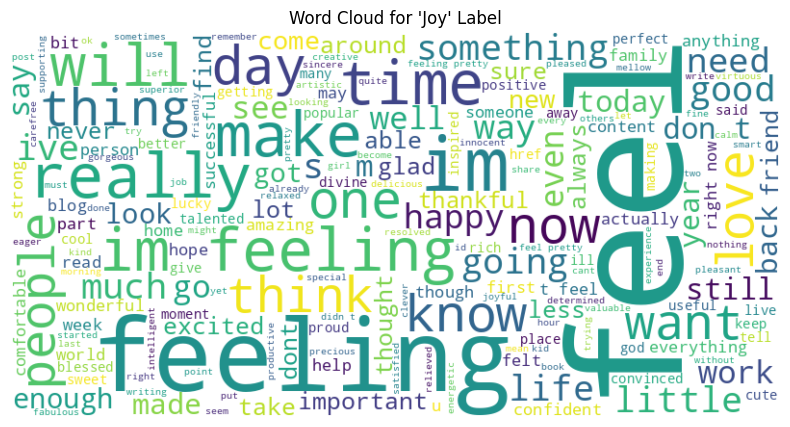

In [ ]:
# joy
joy_texts = train_df[train_df["label"] == "joy"]["text"]
joy_text = " ".join(joy_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(joy_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for 'Joy' Label")
plt.show()

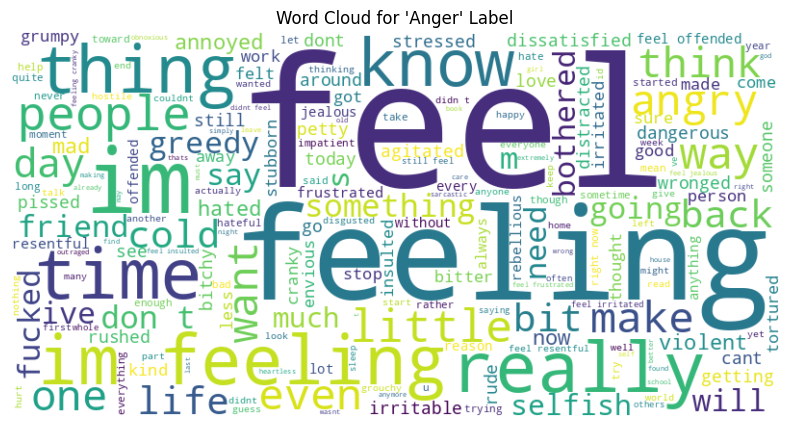

In [ ]:
anger_texts = train_df[train_df["label"] == "anger"]["text"]
anger_text = " ".join(anger_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(anger_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for 'Anger' Label")
plt.show()

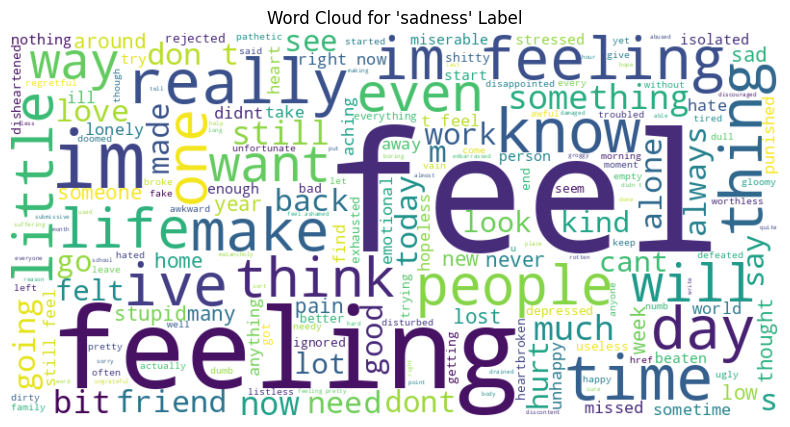

In [ ]:
sadness_texts = train_df[train_df["label"] == "sadness"]["text"]
sadness_text = " ".join(sadness_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(sadness_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for 'sadness' Label")
plt.show()

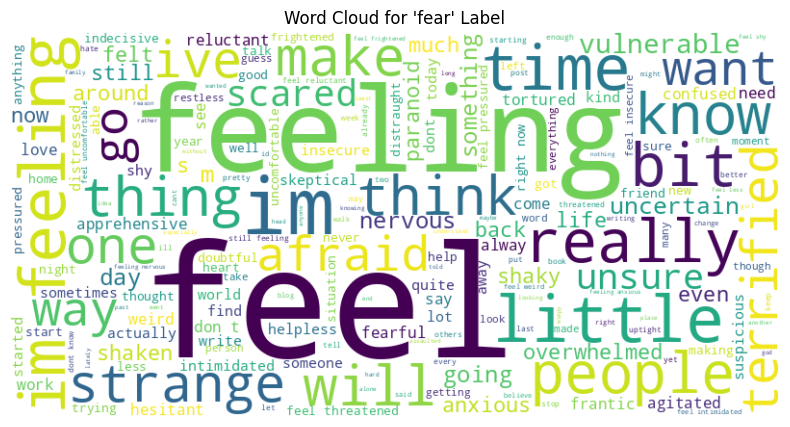

In [ ]:
fear_texts = train_df[train_df["label"] == "fear"]["text"]
fear_text = " ".join(fear_texts)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(fear_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for 'fear' Label")
plt.show()

/tmp/ipython-input-1044879217.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, order=train_df['label'].value_counts().index, palette="pastel")


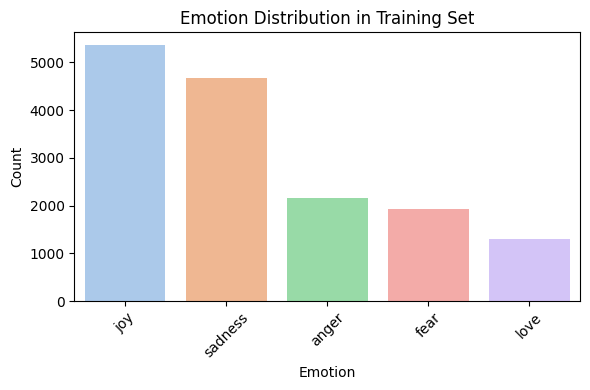

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=train_df, order=train_df['label'].value_counts().index, palette="pastel")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.title("Emotion Distribution in Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# check the average number of words in the text column:
avg_word_count = train_df["text"].str.split().apply(len).mean()
print(avg_word_count)

19.13748622544889


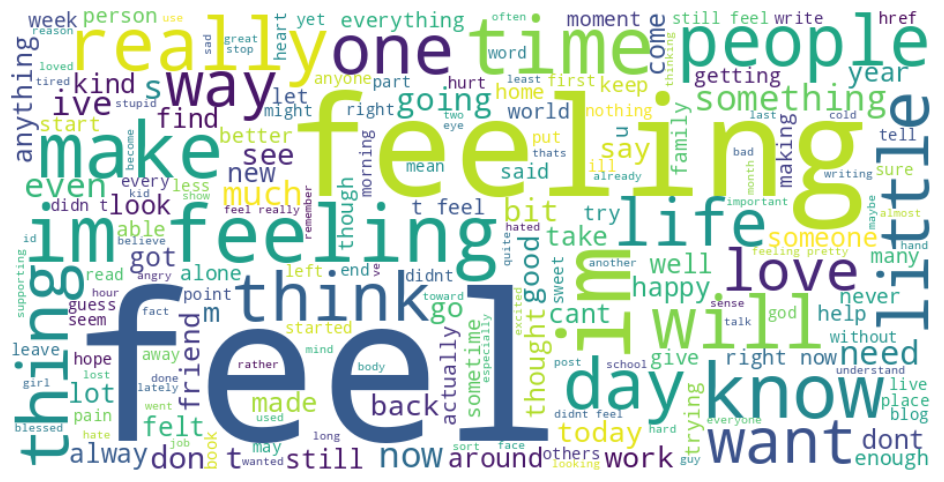

In [ ]:
# word cloud to further visualize:
# Combine all text into one string
from wordcloud import WordCloud
all_text = " ".join(train_df["text"].dropna())

# Create a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


TEXT TO TOKEN CONVERSTION


In [ ]:
from transformers import AutoTokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
tokenizer.vocab_size, tokenizer.model_max_length

(30522, 512)

In [ ]:
# Replace string label column with numeric one
train_df = train_df.drop(columns=["label"])
val_df = val_df.drop(columns=["label"])
test_df = test_df.drop(columns=["label"])

# Rename 'classes' to 'label'
train_df = train_df.rename(columns={"classes": "label"})
val_df = val_df.rename(columns={"classes": "label"})
test_df = test_df.rename(columns={"classes": "label"})

In [ ]:
train_df.head()

,text,label
0,i can go from feeling so hopeless to so damned...,0.0
1,im grabbing a minute to post i feel greedy wrong,3.0
2,i am ever feeling nostalgic about the fireplac...,2.0
3,i am feeling grouchy,3.0
4,ive been feeling a little burdened lately wasn...,0.0


In [ ]:
train_df['label'] = train_df['label'].astype(int)
val_df['label'] = val_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

In [ ]:
train_df.head()

,text,label
0,i can go from feeling so hopeless to so damned...,0
1,im grabbing a minute to post i feel greedy wrong,3
2,i am ever feeling nostalgic about the fireplac...,2
3,i am feeling grouchy,3
4,ive been feeling a little burdened lately wasn...,0


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
val_dataset = Dataset.from_pandas(val_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)



In [ ]:
print(train_dataset.column_names)
print(val_dataset.column_names)
print(test_dataset.column_names)


['text', 'label']
['text', 'label']
['text', 'label']


In [ ]:
train_dataset[1]

{'text': 'im grabbing a minute to post i feel greedy wrong', 'label': 3}

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(tokenize, batched=True)
tokenized_val = val_dataset.map(tokenize, batched=True)
tokenized_test = test_dataset.map(tokenize, batched=True)


Map:   0%|          | 0/15427 [00:00<?, ? examples/s]

Map:   0%|          | 0/1918 [00:00<?, ? examples/s]

Map:   0%|          | 0/1933 [00:00<?, ? examples/s]

In [ ]:
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

In [ ]:
tokenized_train[1]

{'text': 'im grabbing a minute to post i feel greedy wrong',
 'label': tensor(3),
 'input_ids': tensor([  101, 10047,  9775,  1037,  3371,  2000,  2695,  1045,  2514, 20505,
          3308,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,

In [ ]:
from transformers import AutoModel
import torch
model = AutoModel.from_pretrained("distilbert-base-uncased")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
tokenizer.vocab_size, tokenizer.model_max_length

(30522, 512)

In [ ]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): MultiHeadSelfAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Li

In [ ]:
from transformers import AutoModel
import torch
model = AutoModel.from_pretrained("distilbert-base-uncased")

In [ ]:
classes = ["sadness", "joy", "love", "anger", "fear"]


In [ ]:

from transformers import AutoModelForSequenceClassification
num_labels = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels = num_labels).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device

device(type='cuda')

In [ ]:
import transformers
from transformers import TrainingArguments
print(transformers.__version__)
print(TrainingArguments.__module__)
print(TrainingArguments.__doc__)

4.45.0
transformers.training_args

    TrainingArguments is the subset of the arguments we use in our example scripts **which relate to the training loop
    itself**.

    Using [`HfArgumentParser`] we can turn this class into
    [argparse](https://docs.python.org/3/library/argparse#module-argparse) arguments that can be specified on the
    command line.

    Parameters:
        output_dir (`str`):
            The output directory where the model predictions and checkpoints will be written.
        overwrite_output_dir (`bool`, *optional*, defaults to `False`):
            If `True`, overwrite the content of the output directory. Use this to continue training if `output_dir`
            points to a checkpoint directory.
        do_train (`bool`, *optional*, defaults to `False`):
            Whether to run training or not. This argument is not directly used by [`Trainer`], it's intended to be used
            by your training/evaluation scripts instead. See the [example
            s

In [ ]:
!pip install transformers==4.45.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 91.8 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.0
    Uninstalling tokenizers-0.22.0:
      Successfully uninstalled tokenizers-0.22.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.56.1
    Uninstalling transformers-4.56.1:
      Successfully uninstalled transformers-4.56.1


In [ ]:
from transformers import TrainingArguments

batch_size = 64
model_name = "distilbert-finetuned-emotion"

training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=3,
    learning_rate=1e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    disable_tqdm=False
)


/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
import transformers
print(transformers.__version__)

4.45.0


In [ ]:
from transformers import TrainingArguments
print(TrainingArguments)

<class 'transformers.training_args.TrainingArguments'>


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy: ": acc, "f1": f1}

In [ ]:
from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer
)

trainer.train()
train_result = trainer.train()
metrics = train_result.metrics


Epoch,Training Loss,Validation Loss,Accuracy:,F1
1,0.058500,0.141819,0.944213,0.943720
2,0.040500,0.140562,0.945255,0.945380
3,0.038900,0.146812,0.947341,0.947440


Epoch,Training Loss,Validation Loss,Accuracy:,F1
1,0.033900,0.165808,0.946298,0.946031
2,0.026600,0.166698,0.947862,0.947838
3,0.027900,0.170694,0.948384,0.948423


In [ ]:
# Save final model
trainer.save_model("huggingface_BERT_RUN3_3epoch")



In [ ]:
# Save tokenizer
tokenizer.save_pretrained("tokenizer_bert_run2")

('tokenizer_bert_run2/tokenizer_config.json',
 'tokenizer_bert_run2/special_tokens_map.json',
 'tokenizer_bert_run2/vocab.txt',
 'tokenizer_bert_run2/added_tokens.json',
 'tokenizer_bert_run2/tokenizer.json')

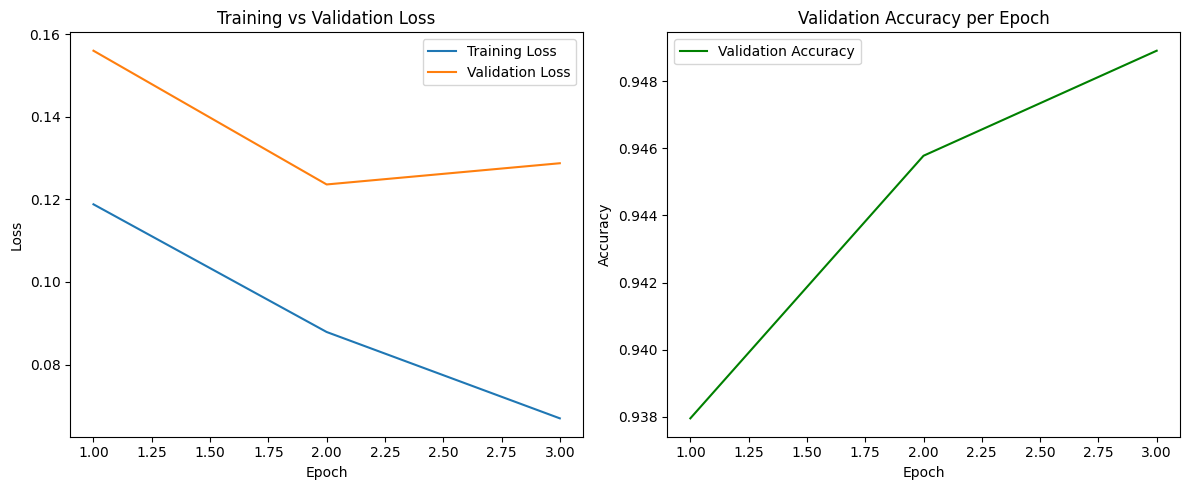

In [ ]:
# plotting graphs: import matplotlib.pyplot as plt

# Get log history
logs = trainer.state.log_history

train_loss = [entry["loss"] for entry in logs if "loss" in entry]
eval_loss = [entry["eval_loss"] for entry in logs if "eval_loss" in entry]
eval_accuracy = [entry["eval_accuracy: "] for entry in logs if "eval_accuracy: " in entry]

epochs = list(range(1, len(eval_accuracy)+1))

# Plot loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, eval_accuracy, label="Validation Accuracy", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.legend()

plt.tight_layout()
plt.show()



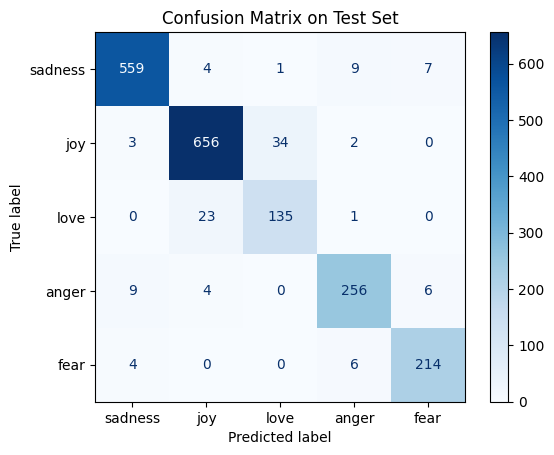

In [ ]:
# confusion matrix:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
predictions = trainer.predict(tokenized_test)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.show()


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch


model_dir = "/content/huggingface_BERT_RUN3_3epoch"

# Load tokenizer and model
tokenizer =DistilBertTokenizer.from_pretrained(model_dir)
model =DistilBertForSequenceClassification.from_pretrained(model_dir)


In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch




texts = [
    "I am feeling under the weather. I want to feel calm under all the chaos aruond me like a Sunday evening after coming home from an outing",
    "It was a busy day at work. I had a ton of clients to see but it was a good and productive work day all in all",
    "I'm actually so stressed ad tired because my daughter has such a high fever. So I'm waiting for her fever to break. She came home from school with a fever"
]

# Tokenize
encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    return_tensors="pt"
)

# Predict
with torch.no_grad():
    outputs = model(**encodings)
    logits = outputs.logits

# Convert logits to probabilities
probs = torch.nn.functional.softmax(logits, dim=-1)

# Get predicted labels
predicted_classes = torch.argmax(probs, dim=1)

# Print results
for text, pred, prob in zip(texts, predicted_classes, probs):
    print("Text:", text)
    print("Predicted class index:", pred.item())
    print("Probabilities:", prob.tolist())
    print()


Text: I am feeling under the weather. I want to feel calm under all the chaos aruond me like a Sunday evening after coming home from an outing
Predicted class index: 1
Probabilities: [0.0005046508740633726, 0.9974822402000427, 0.00047973066102713346, 0.000755292596295476, 0.0007781084859743714]

Text: It was a busy day at work. I had a ton of clients to see but it was a good and productive work day all in all
Predicted class index: 1
Probabilities: [0.0009355624206364155, 0.9964991807937622, 0.000695298018399626, 0.0013656405499204993, 0.0005042977863922715]

Text: I'm actually so stressed ad tired because my daughter has such a high fever. So I'm waiting for her fever to break. She came home from school with a fever
Predicted class index: 0
Probabilities: [0.5212355852127075, 0.0067220525816082954, 0.0015745963901281357, 0.4635010361671448, 0.006966652814298868]



In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

In [ ]:
import numpy as np
preds_outputs = trainer.predict(tokenized_test)
preds_outputs.metrics

{'test_loss': 0.19203677773475647,
 'test_accuracy: ': 0.9415416451112261,
 'test_f1': 0.9419277960320526,
 'test_runtime': 7.1325,
 'test_samples_per_second': 271.012,
 'test_steps_per_second': 4.346}